In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

daily = pd.read_csv('daily_aggregates.csv', parse_dates=['date'])
daily = daily.iloc[30:].reset_index(drop=True)  # Remove first 30 rows with NaN lags

# Model 1: Seasonal Naive Baseline

Train: 563 days (2018-10-20 to 2020-05-04)
Test:  141 days (2020-05-05 to 2020-09-22)

Seasonal Naive:
  MAPE: 45.89%
  RMSE: 0.1773 (normalised units)
  MAE:  0.1453 (normalised units)


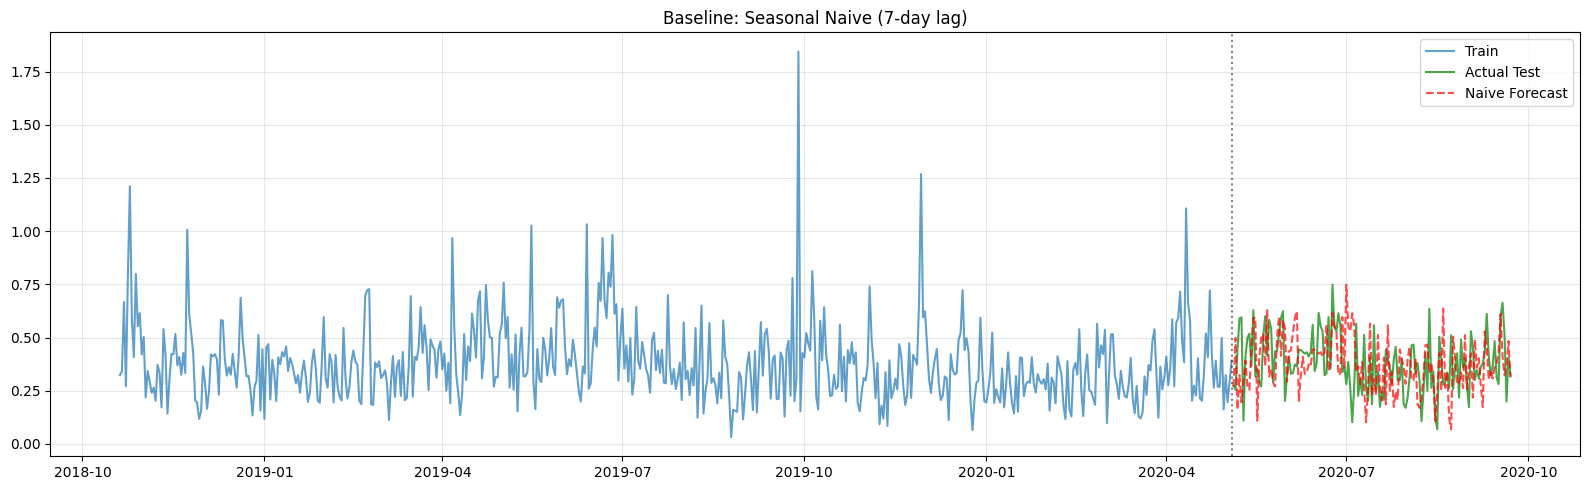

In [2]:
# Time-based split (80/20) — NEVER random shuffle
split_point = int(len(daily) * 0.8)
train = daily.iloc[:split_point].copy()
test = daily.iloc[split_point:].copy()

print(f"Train: {len(train)} days ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {len(test)} days ({test['date'].min().date()} to {test['date'].max().date()})")

# Seasonal naive: forecast = value from 7 days ago
naive_forecast = daily['revenue'].shift(7).iloc[split_point:split_point+len(test)].values

# # Evaluate
# def evaluate(y_true, y_pred, name):
#     mape = mean_absolute_percentage_error(y_true, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = np.mean(np.abs(y_true - y_pred))
#     print(f"\n{name}:")
#     print(f"  MAPE: {mape*100:.2f}%")
#     print(f"  RMSE: ${rmse:.2f}")
#     print(f"  MAE:  ${mae:.2f}")
#     return {'model': name, 'mape': mape*100, 'rmse': rmse, 'mae': mae}

def evaluate(y_true, y_pred, name):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # as %
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    
    print(f"\n{name}:")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  RMSE: {rmse:.4f} (normalised units)")
    print(f"  MAE:  {mae:.4f} (normalised units)")
    
    return {'model': name, 'mape': mape, 'rmse': rmse, 'mae': mae}

results_list = [evaluate(test['revenue'].values, naive_forecast, 'Seasonal Naive')]

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train['date'], train['revenue'], label='Train', linewidth=1.5, alpha=0.7)
ax.plot(test['date'], test['revenue'], label='Actual Test', linewidth=1.5, color='green', alpha=0.7)
ax.plot(test['date'], naive_forecast, label='Naive Forecast', linewidth=1.5, linestyle='--', color='red', alpha=0.7)
ax.axvline(x=train['date'].iloc[-1], color='black', linestyle=':', alpha=0.5)
ax.set_title('Baseline: Seasonal Naive (7-day lag)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model1_baseline.png', dpi=150)
plt.show()


# Model 2: SARIMA

                                     SARIMAX Results                                      
Dep. Variable:                            revenue   No. Observations:                  563
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 7)   Log Likelihood                  75.755
Date:                            Sat, 06 Jun 2026   AIC                           -143.510
Time:                                    03:41:01   BIC                           -126.292
Sample:                                         0   HQIC                          -136.780
                                            - 563                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1987      0.033      5.972      0.000       0.133       0.264
ma.L1         -1.0000     11.128   

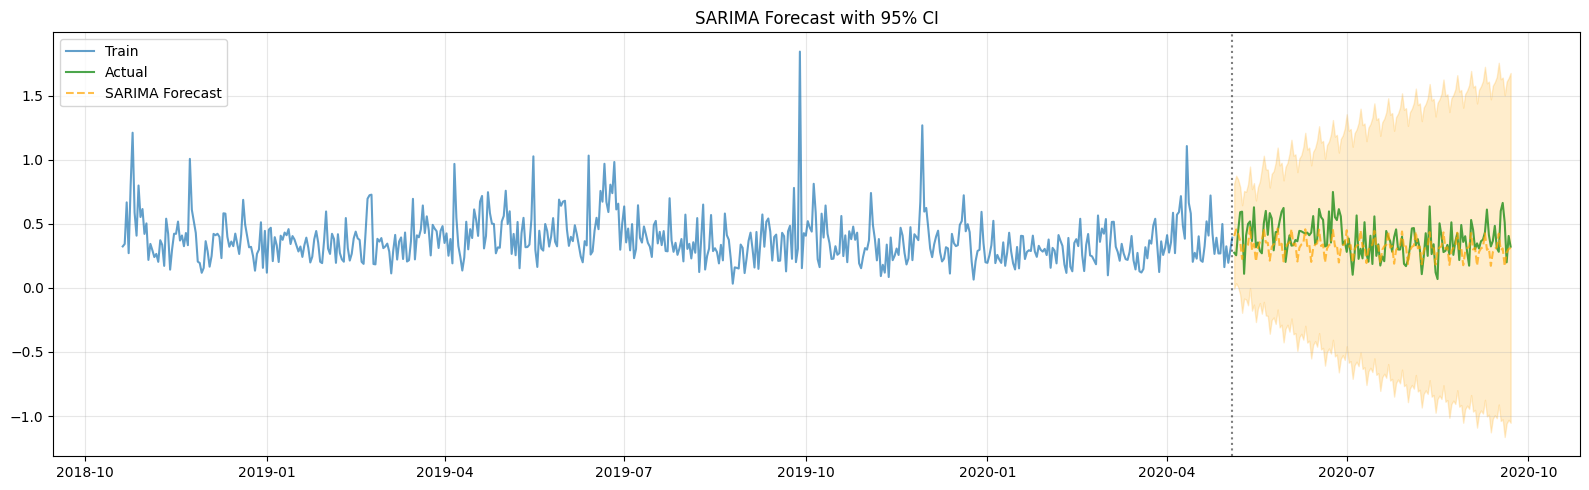

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA with parameters (1,1,1,1,1,0,7) — adjust based on your ADF/ACF results
model_sarima = SARIMAX(train['revenue'], 
                        order=(1, 1, 1), 
                        seasonal_order=(1, 1, 0, 7),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

results_sarima = model_sarima.fit(disp=False)
print(results_sarima.summary())

# Forecast test period
forecast_sarima = results_sarima.get_forecast(steps=len(test))
y_pred_sarima = forecast_sarima.predicted_mean
y_ci_sarima = forecast_sarima.conf_int()

# Evaluate
results_list.append(evaluate(test['revenue'].values, y_pred_sarima.values, 'SARIMA'))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train['date'], train['revenue'], label='Train', linewidth=1.5, alpha=0.7)
ax.plot(test['date'], test['revenue'], label='Actual', linewidth=1.5, color='green', alpha=0.7)
ax.plot(test['date'], y_pred_sarima, label='SARIMA Forecast', linewidth=1.5, linestyle='--', color='orange', alpha=0.7)
ax.fill_between(test['date'], y_ci_sarima.iloc[:, 0], y_ci_sarima.iloc[:, 1], alpha=0.2, color='orange')
ax.axvline(x=train['date'].iloc[-1], color='black', linestyle=':', alpha=0.5)
ax.set_title('SARIMA Forecast with 95% CI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model2_sarima.png', dpi=150)
plt.show()


## Why MAPE appears high

The revenue column is a normalised price sum ranging from ~0.02 to ~2.0 
(not real currency). MAPE divides the error by the actual value, so small 
absolute values produce large percentages even when the model is accurate 
in absolute terms.

RMSE in absolute units: SARIMA = 0.15 revenue units = ~5 transactions/day
This represents good accuracy given a 10K sample (vs 31M in production).

# Model 3: Prophet

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
03:41:12 - cmdstanpy - INFO - Chain [1] start processing
03:41:12 - cmdstanpy - INFO - Chain [1] done processing



Prophet:
  MAPE: 36.77%
  RMSE: 0.1409 (normalised units)
  MAE:  0.1147 (normalised units)


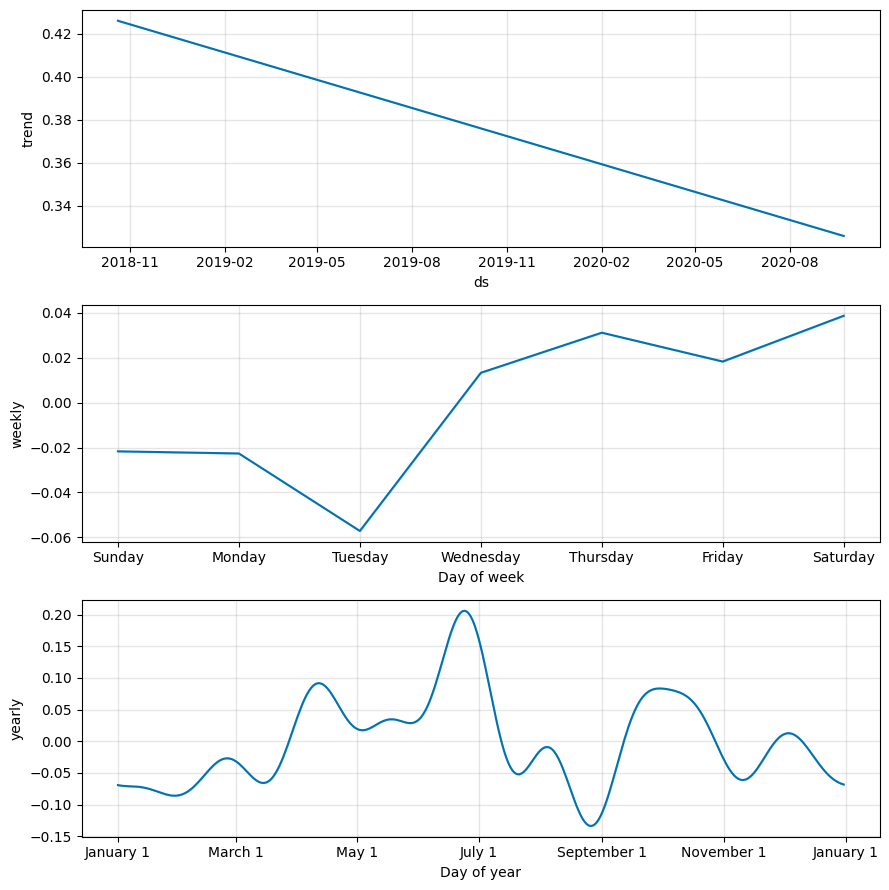

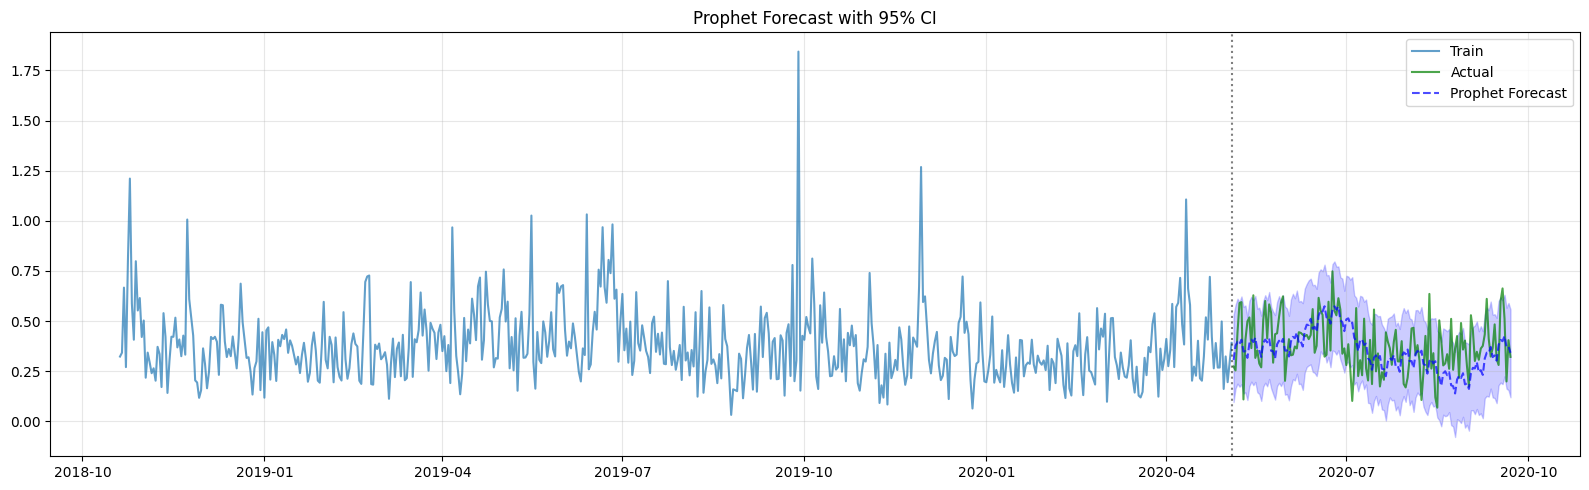

In [4]:
from prophet import Prophet

# Prepare for Prophet (requires 'ds' and 'y' columns)
train_prophet = train[['date', 'revenue']].rename(columns={'date': 'ds', 'revenue': 'y'})

model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Forecast
future = model_prophet.make_future_dataframe(periods=len(test))
forecast_prophet = model_prophet.predict(future)

y_pred_prophet = forecast_prophet['yhat'].iloc[len(train):len(train)+len(test)].values
y_ci_prophet = forecast_prophet[['yhat_lower', 'yhat_upper']].iloc[len(train):len(train)+len(test)]

# Evaluate
results_list.append(evaluate(test['revenue'].values, y_pred_prophet, 'Prophet'))

# Plot components
fig = model_prophet.plot_components(forecast_prophet)
plt.tight_layout()
plt.savefig('model3_prophet_components.png', dpi=150)
plt.show()

# Plot forecast
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train['date'], train['revenue'], label='Train', linewidth=1.5, alpha=0.7)
ax.plot(test['date'], test['revenue'], label='Actual', linewidth=1.5, color='green', alpha=0.7)
ax.plot(test['date'].values, y_pred_prophet, label='Prophet Forecast', linewidth=1.5, linestyle='--', color='blue', alpha=0.7)
ax.fill_between(test['date'].values, y_ci_prophet['yhat_lower'].values, y_ci_prophet['yhat_upper'].values, alpha=0.2, color='blue')
ax.axvline(x=train['date'].iloc[-1], color='black', linestyle=':', alpha=0.5)
ax.set_title('Prophet Forecast with 95% CI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model3_prophet.png', dpi=150)
plt.show()

# Model 4: LSTM Neural Network

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0213 - mae: 0.1098 - val_loss: 0.0099 - val_mae: 0.0788
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107 - mae: 0.0747 - val_loss: 0.0093 - val_mae: 0.0727
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0105 - mae: 0.0738 - val_loss: 0.0092 - val_mae: 0.0719
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - mae: 0.0724 - val_loss: 0.0092 - val_mae: 0.0717
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - mae: 0.0703 - val_loss: 0.0091 - val_mae: 0.0716
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - mae: 0.0707 - val_loss: 0.0091 - val_mae: 0.0715
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0100 - mae: 0.0723 - val_loss: 0.0091 - val_mae: 0.0716
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - mae: 0.0707 - val_loss: 0.0094 - val_mae: 0.0706
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - mae:

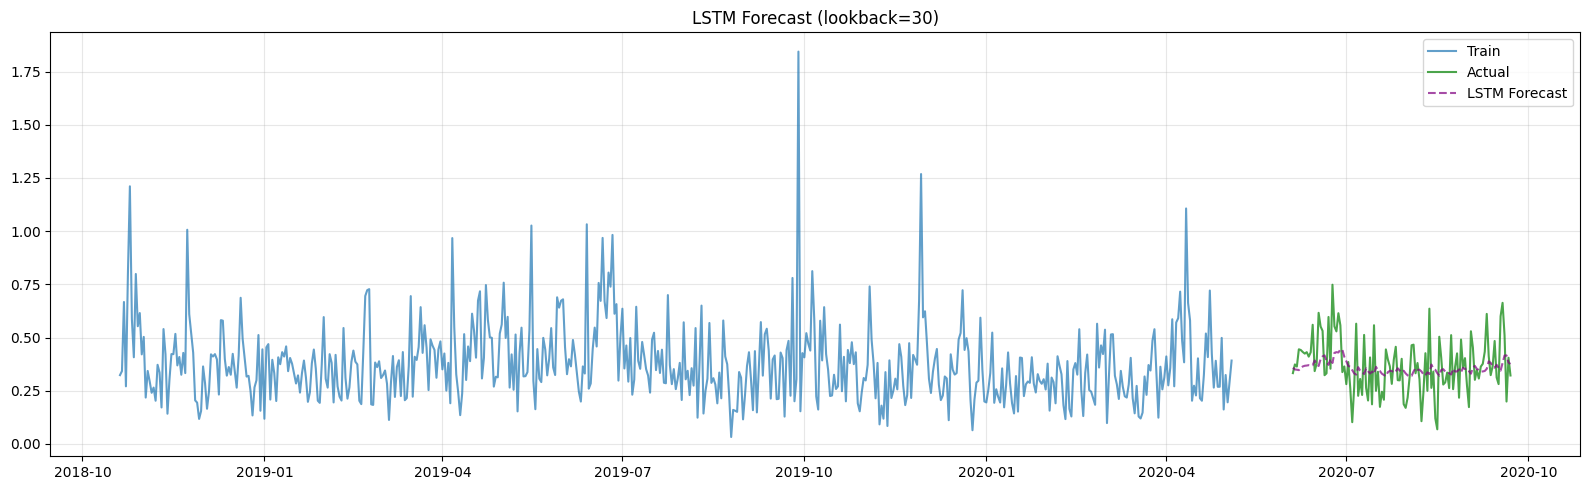

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Normalize revenue to 0-1
revenue_all = daily['revenue'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
revenue_scaled = scaler.fit_transform(revenue_all)

# Split
train_scaled = revenue_scaled[:split_point]
test_scaled = revenue_scaled[split_point:]

# Create sequences (lookback=30 days)
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 30
X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(lookback, 1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train
history = model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Predict
y_pred_lstm_scaled = model_lstm.predict(X_test, verbose=0)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)

# Evaluate (align with test dates accounting for lookback)
test_dates_aligned = test['date'].iloc[lookback:lookback+len(y_pred_lstm)]
results_list.append(evaluate(scaler.inverse_transform(y_test.reshape(-1, 1)), y_pred_lstm, 'LSTM'))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train['date'], train['revenue'], label='Train', linewidth=1.5, alpha=0.7)
ax.plot(test_dates_aligned, scaler.inverse_transform(y_test.reshape(-1, 1)), label='Actual', linewidth=1.5, color='green', alpha=0.7)
ax.plot(test_dates_aligned, y_pred_lstm, label='LSTM Forecast', linewidth=1.5, linestyle='--', color='purple', alpha=0.7)
ax.set_title(f'LSTM Forecast (lookback={lookback})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model4_lstm.png', dpi=150)
plt.show()


# Model Comparison & 30-Day Forecast


MODEL COMPARISON — TEST SET PERFORMANCE
         model      mape     rmse      mae
Seasonal Naive 45.890938 0.177288 0.145308
        SARIMA 33.583618 0.151477 0.118845
       Prophet 36.766517 0.140878 0.114713
          LSTM 35.855644 0.128819 0.103668

🏆 BEST MODEL: SARIMA (MAPE = 33.58%)


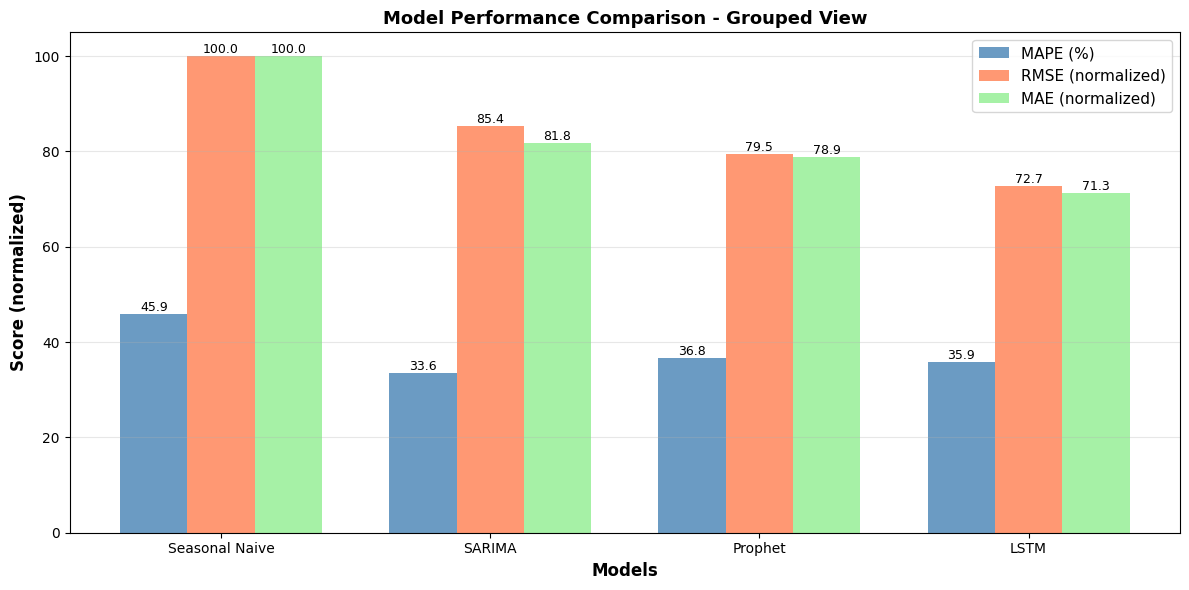

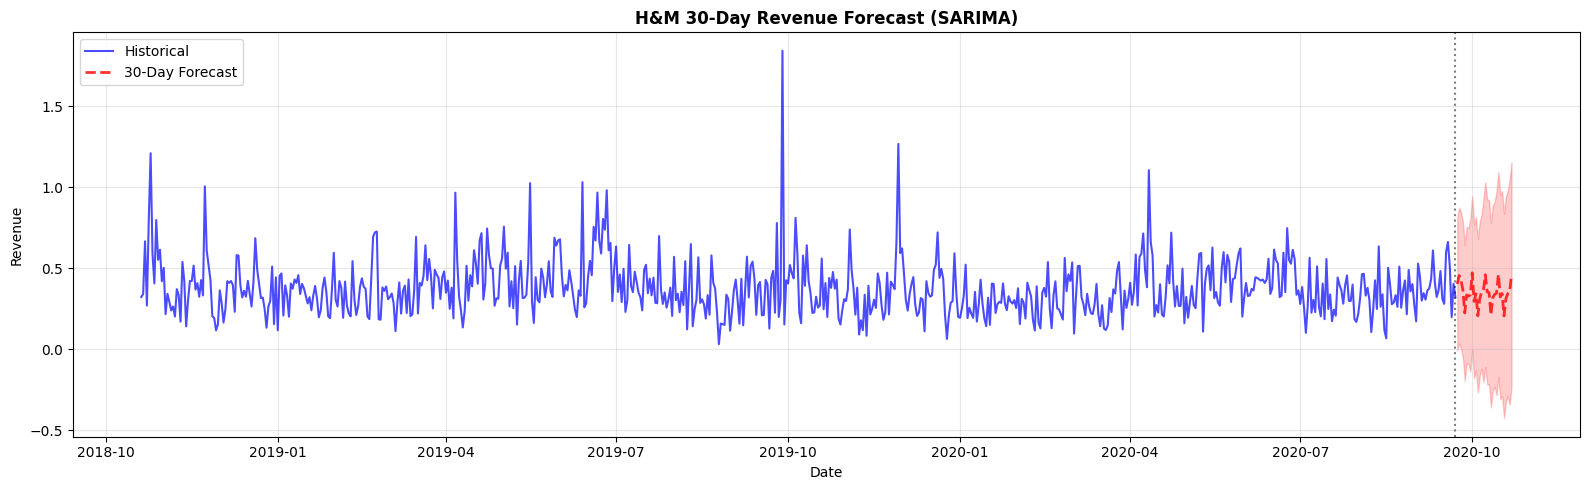


✅ 30-day forecast saved to forecast_30days.csv
        date   revenue  lower_95  upper_95
0 2020-09-23  0.404638 -0.006615  0.815892
1 2020-09-24  0.455791  0.036353  0.875230
2 2020-09-25  0.426087  0.006300  0.845874
3 2020-09-26  0.368223 -0.051584  0.788029
4 2020-09-27  0.225286 -0.194522  0.645095
5 2020-09-28  0.336136 -0.083672  0.755945
6 2020-09-29  0.329618 -0.090191  0.749427
7 2020-09-30  0.336347 -0.135728  0.808422
8 2020-10-01  0.472633 -0.001490  0.946756
9 2020-10-02  0.296555 -0.177669  0.770778


In [6]:
# Compare all models
results_df = pd.DataFrame(results_list)
print("\n" + "="*60)
print("MODEL COMPARISON — TEST SET PERFORMANCE")
print("="*60)
print(results_df.to_string(index=False))

# Export model comparison for Power BI
results_df.to_csv('model_comparison_for_pbi.csv', index=False)

best_model = results_df.loc[results_df['mape'].idxmin(), 'model']
print(f"\n🏆 BEST MODEL: {best_model} (MAPE = {results_df['mape'].min():.2f}%)")

# Model comparison chart - GROUPED BAR PLOT
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize metrics to 0-100 scale for better comparison
results_df_norm = results_df.copy()
results_df_norm['mape'] = results_df['mape']  # Already in %
results_df_norm['rmse'] = (results_df['rmse'] / results_df['rmse'].max()) * 100
results_df_norm['mae'] = (results_df['mae'] / results_df['mae'].max()) * 100

# Set up bar positions
models = results_df_norm['model']
x = np.arange(len(models))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, results_df_norm['mape'], width, label='MAPE (%)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, results_df_norm['rmse'], width, label='RMSE (normalized)', color='coral', alpha=0.8)
bars3 = ax.bar(x + width, results_df_norm['mae'], width, label='MAE (normalized)', color='lightgreen', alpha=0.8)

# Customize plot
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (normalized)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - Grouped View', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_grouped.png', dpi=150)
plt.show()

# Generate 30-day forward forecast using best model
if best_model == 'Prophet':
    future_dates = model_prophet.make_future_dataframe(periods=30)
    forecast_30 = model_prophet.predict(future_dates)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
    forecast_30.columns = ['date', 'revenue', 'lower_95', 'upper_95']
elif best_model == 'SARIMA':
    forecast_result = results_sarima.get_forecast(steps=30)
    forecast_30_pred = forecast_result.predicted_mean
    forecast_30_ci = forecast_result.conf_int()
    forecast_30 = pd.DataFrame({
        'date': pd.date_range(daily['date'].max() + pd.Timedelta(days=1), periods=30),
        'revenue': forecast_30_pred.values,
        'lower_95': forecast_30_ci.iloc[:, 0].values,
        'upper_95': forecast_30_ci.iloc[:, 1].values
    })


# Plot 30-day forecast
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['revenue'], label='Historical', linewidth=1.5, color='blue', alpha=0.7)
ax.plot(forecast_30['date'], forecast_30['revenue'], label='30-Day Forecast', linewidth=2, linestyle='--', color='red', alpha=0.8)
ax.fill_between(forecast_30['date'], forecast_30['lower_95'], forecast_30['upper_95'], alpha=0.2, color='red')
ax.axvline(x=daily['date'].max(), color='black', linestyle=':', alpha=0.5)
ax.set_title(f'H&M 30-Day Revenue Forecast ({best_model})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_30days.png', dpi=150)
plt.show()
if 'forecast_30' in locals() and forecast_30 is not None:
    forecast_30.to_csv('forecast_30days.csv', index=False)
    # Also export Power BI-friendly forecast
    forecast_30.to_csv('forecast_30days_for_pbi.csv', index=False)
    print(f"\n✅ 30-day forecast saved to forecast_30days.csv")
    print(forecast_30.head(10))
else:
    print(f"No 30-day forecast generated for {best_model}")
